✅ Notes for this setup

- No feature scaling → XGBoost doesn’t need it.

- No need to drop multicollinear features → trees handle it naturally.

- Default hyperparameters already give strong performance.

Later you can:

- Tune max_depth, learning_rate, n_estimators.

- Use early_stopping_rounds with a validation set.

- Check feature importance with xgb.feature_importances_.

In [ ]:
# ================================================
# 1. Imports
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ================================================
# 2. Load datasets (feature engineered, leakage-safe)
# ================================================
df_train = pd.read_csv("../data/processed/feature_engineered_train.csv")
df_eval = pd.read_csv("../data/processed/feature_engineered_eval.csv")

# ================================================
# 3. Define target & features
# ================================================
target = "price"

X_train = df_train.drop(columns=[target])
y_train = df_train[target]

X_eval = df_eval.drop(columns=[target])
y_eval = df_eval[target]

print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

# ================================================
# 4. Train a simple XGBoost Regressor
# ================================================
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ================================================
# 5. Evaluate performance
# ================================================
y_pred = xgb_model.predict(X_eval)

mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print("XGBoost Performance:")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")


Train shape: (576815, 39)
Eval shape: (148448, 39)
XGBoost Performance:
MAE: 32,928.45
RMSE: 74,639.47
R²: 0.9569


In [ ]:
# ================================================
# 5. Evaluate performance (Updated with Overfit Check)
# ================================================

# Generate predictions for both datasets
y_pred_train = xgb_model.predict(X_train)
y_pred_eval = xgb_model.predict(X_eval)

# Training Metrics
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Evaluation Metrics
mae_eval = mean_absolute_error(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mean_squared_error(y_eval, y_pred_eval))
r2_eval = r2_score(y_eval, y_pred_eval)

print("--- Performance Comparison ---")
print(f"R² Train: {r2_train:.4f} | R² Eval: {r2_eval:.4f}")
print(f"RMSE Train: {rmse_train:,.2f} | RMSE Eval: {rmse_eval:,.2f}")
print(f"MAE Train: {mae_train:,.2f} | MAE Eval: {mae_eval:,.2f}")

# Overfitting Analysis Logic
gap_r2 = r2_train - r2_eval
if gap_r2 > 0.1:
    print(f"\n⚠️ ALERT: Potential OVERFITTING detected! (Gap R²: {gap_r2:.4f})")
    print("Action: Increase regularization (alpha/lambda) or reduce max_depth.")
elif gap_r2 < 0:
    print("\n💡 INFO: Eval performance exceeds Train. Unusual (Check for Underfitting or Data Leakage).")
else:
    print("\n✅ Model is stable and well-generalized.")

--- Performance Comparison ---
R² Train: 0.9902 | R² Eval: 0.9569
RMSE Train: 29,807.44 | RMSE Eval: 74,639.47
MAE Train: 18,564.63 | MAE Eval: 32,928.45

✅ Model cukup stabil (Well-generalized).


In [6]:
X_train.columns

Index(['year', 'quarter', 'month', 'median_list_price', 'median_ppsf',
       'median_list_ppsf', 'homes_sold', 'pending_sales', 'new_listings',
       'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
       'off_market_in_two_weeks', 'bank', 'bus', 'hospital', 'mall', 'park',
       'restaurant', 'school', 'station', 'supermarket', 'Total Population',
       'Median Age', 'Per Capita Income', 'Total Families Below Poverty',
       'Total Housing Units', 'Median Rent', 'Median Home Value',
       'Total Labor Force', 'Unemployed Population',
       'Total School Age Population', 'Total School Enrollment',
       'Median Commute Time', 'lat', 'lng', 'zipcode_freq', 'city_encoded'],
      dtype='object')

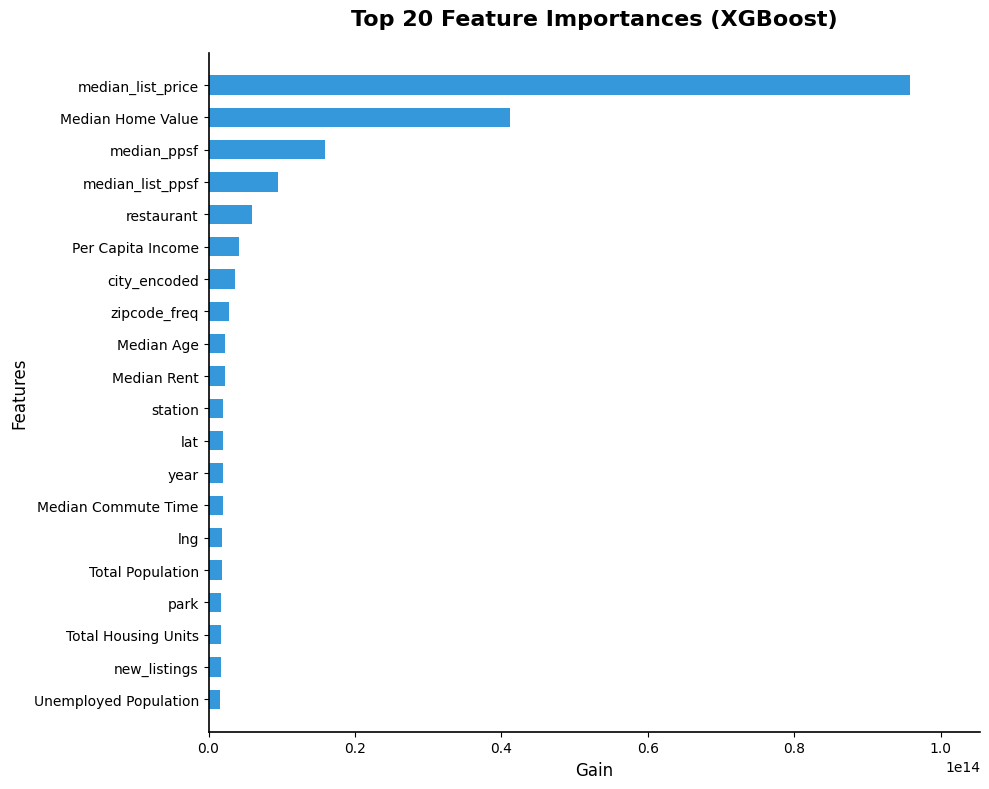

In [ ]:
# Use subplots for flexible axis management
fig, ax = plt.subplots(figsize=(10, 8))

# Visualize top 20 features based on 'Gain'
plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.6,
    show_values=False,
    ax=ax,          # Map plot to the existing axis
    grid=False,     # Disable grid within XGBoost function
    color="#3498db" # Professional blue for a clean aesthetic
)

# Ensure grid lines are removed
ax.grid(False)

# Modernize layout by removing top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Set professional title and labels
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Gain", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()